# Бейзлайн оптимизации автобусной сети Кудрово → метро «Улица Дыбенко»

**Курсовая: «Моделирование маршрутов общественного транспорта … (пригороды Санкт-Петербурга)»**

## Что это и зачем
Это **бейзлайн** — простой, «до-ML» способ построить автобусную сеть. Он нужен как
**точка отсчёта**: относительно него далее сравниваются методы машинного обучения
(генетический алгоритм, RL). Если ML даёт меньшее среднее время — это и есть результат.

Бейзлайн = **конструктивная эвристика + локальный поиск** (схема Pattnaik, 1998):
генерируем пул маршрутов-кандидатов кратчайшими путями по графу дорог, затем жадно
отбираем лучший поднабор и раздаём парк машин. **Кластеризации здесь намеренно нет** —
это простой топологический метод, и его задача — показать, что простые альтернативы
существуют, но уступают ML.

## Архитектура (поток данных)
```
Данные (.gpkg, .csv)
   │
   ├─ kud_roads_buses_v3 ──► ГРАФ автобусной сети (networkx, направленный, с oneway)
   │                            │
   ├─ bus_stops_v2 ────────────┤──► времена остановка→метро и остановка→остановка
   │                            │
   ├─ Кудрово_парадные ────────┤──► СПРОС: население подъездов
   │                            │
   └─ od_matrix_topk ──────────┘──► пешие времена подъезд→(top-3 остановки)
                                │
                  ГЕНЕРАЦИЯ КАНДИДАТОВ (k-кратчайших путей + существующие маршруты)
                                │
                  ЖАДНЫЙ ОТБОР + SWAP  ◄── фитнес = T_avg
                                │
                  РАЗДАЧА ПАРКА (sqrt-rule) → интервалы, провозимость
                                │
                  РЕЗУЛЬТАТ: маршруты (.gpkg) + метрика T_avg + карта
```

## Метрика (минимизируем)
$$T_{avg}=\frac{\sum_i pop_i \cdot T_i}{\sum_i pop_i},\quad
T_i = t_{walk}+t_{wait}+t_{invehicle}+n_{stops}\cdot t_{dwell}$$

## Файлы, которые должны лежать рядом с ноутбуком
`kud_roads_buses_v3.gpkg`, `bus_stops_v2.gpkg`, `Кудрово_парадные.gpkg`,
`od_matrix_topk.csv`, `OUTPUT.gpkg` (для сравнения с существующей сетью).


## 1. Параметры модели
Все допущения собраны здесь — **меняйте только этот блок**.

In [162]:
import json, pickle, numpy as np, pandas as pd, geopandas as gpd, networkx as nx
from shapely.geometry import LineString
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

CRS = 32636  # метрическая проекция (UTM 36N) — все расстояния в метрах

# ── ПАРАМЕТРЫ (допущения для отчёта) ─────────────────────────────────────────
P = dict(
    walk_speed_mps   = 5*1000/3600,   # пешая скорость 5 км/ч
    bus_cruise_kmh   = 40,            # дефолтный лимит скорости, если нет maxspeed
    bus_speed_factor = 0.65,          # реальная скорость = 0.65 * лимит (трафик/светофоры)
    dwell_s          = 29,            # потеря времени на 1 остановку, с (константа из литературы)
    layover_factor   = 1.15,          # оборотное время = 2*(в пути)*коэф (отстой на конце)
    # цепочка отсева «население → реальные пассажиры к метро» (по Шлеину, ВШЭ 2026):
    alpha_zan        = 0.568,         # доля занятого населения
    beta_vyezd       = 0.7,           # доля работающих вне района
    gamma_ot         = 0.565,         # доля пользователей ОТ среди занятых
    k_shortest       = 3,             # сколько кратчайших путей берём от каждой остановки-семени
    n_seeds          = 44,            # сколько остановок используем как семена (44 = все)
    max_routes       = 8,             # верхняя граница числа маршрутов в сети
    unserved_penalty_s = 3600,        # штраф подъезду, если ни одна из top-3 остановок не обслуживается
    peak_hours       = 2.0,           # длительность утреннего пика, ч (Шлеин: 7-10 = 3ч; берём 2ч)
    min_stops        = 3,             # минимум остановок в маршруте, не считая метро
    stop_dedup_m     = 206,             # схлопывать соседние остановки маршрута ближе этого расстояния, м
)
P['commuter_share'] = P['alpha_zan']*P['beta_vyezd']*P['gamma_ot']   # ≈ 0.225

P['commuter_share'] = 0.15   # скорректированная оценка доли коммьютеров на ОТ
# (раньше = alpha*beta*gamma ≈ 0.225). Влияет на поток и overflow-штраф.
print("Доля жителей, едущих к метро на ОТ (commuter_share):", round(P['commuter_share'],3))

# ── ПАРК (смешанный): ЛиАЗ-5292 ×8 (117 чел) + Volgabus-4298 ×10 (49 чел) ──────
def make_fleet(n_liaz, n_volga):
    return sorted([117]*n_liaz + [49]*n_volga, reverse=True)

FLEET = make_fleet(8, 10)   # фактический парк = 18 машин
print("Парк:", len(FLEET), "машин, суммарная вместимость", sum(FLEET), "чел/рейс")

Доля жителей, едущих к метро на ОТ (commuter_share): 0.15
Парк: 18 машин, суммарная вместимость 1426 чел/рейс


## 2. Граф автобусной сети
Из слоя дорог строим **направленный** граф: двусторонние дороги → два ребра, `oneway=yes` → одно. Вес ребра = время = длина / скорость.

In [163]:
def parse_maxspeed(v, default_kmh):
    if v is None or (isinstance(v,float) and np.isnan(v)): return default_kmh
    s = str(v)
    if s == 'RU:urban': return 60
    try: return float(s.split()[0])
    except: return default_kmh

def build_bus_graph(roads_gpkg, layer='doroga_for_busiki'):
    gdf = gpd.read_file(roads_gpkg, layer=layer).to_crs(CRS).explode(index_parts=False)
    G = nx.DiGraph()
    for _, row in gdf.iterrows():
        g = row.geometry
        if g is None or g.is_empty: continue
        v = parse_maxspeed(row.get('maxspeed'), P['bus_cruise_kmh']) * P['bus_speed_factor'] * 1000/3600
        oneway = (row.get('oneway') == 'yes')
        c = list(g.coords)
        for i in range(len(c)-1):
            u = (round(c[i][0],1),   round(c[i][1],1))
            w = (round(c[i+1][0],1), round(c[i+1][1],1))
            if u == w: continue
            L = LineString([c[i], c[i+1]]).length
            G.add_edge(u, w, length=L, time=L/v)
            if not oneway: G.add_edge(w, u, length=L, time=L/v)
    for n in G.nodes: G.nodes[n]['x'], G.nodes[n]['y'] = n
    # крупнейшая сильносвязная компонента — чтобы Dijkstra не упирался в тупики
    return G.subgraph(max(nx.strongly_connected_components(G), key=len)).copy()

G = build_bus_graph(r"C:\Users\georg\NIS\Curse_work_2026\kud_roads_buses_v3.gpkg")
print("Граф:", G.number_of_nodes(), "узлов,", G.number_of_edges(), "рёбер")

Граф: 1385 узлов, 2709 рёбер


## 3. Спрос и пешие времена
Подъезды с населением + OD-матрица (пешие расстояния до 3 ближайших остановок).

Остановки метро «Дыбенко» — это **сток** (назначение), их исключаем из посадочных.

In [164]:
ent = gpd.read_file(r'C:/Users/georg/Downloads/paradniye_with_pop_v2.gpkg').to_crs(CRS).reset_index(drop=True)
ent['entrance_id'] = ent.index + 1
ent_pop = ent.set_index('entrance_id')['population']

stops = gpd.read_file(r'C:\Users\georg\NIS\Curse_work_2026\bus_stops_v2.gpkg').to_crs(CRS).reset_index(drop=True)
is_metro = stops['name'].astype(str).str.contains('Дыбенко', na=False)
board = stops[~is_metro].reset_index(drop=True)   # посадочные остановки
metro = stops[is_metro].reset_index(drop=True)    # сток
print(f"Подъездов: {len(ent)}, население: {ent_pop.sum():.0f}")
print(f"Посадочных остановок: {len(board)}, точек метро: {len(metro)}")

Подъездов: 621, население: 102848
Посадочных остановок: 44, точек метро: 7


### 3.1 Восстановление соответствия stop_id ↔ остановка
В `od_matrix_topk.csv` остановки пронумерованы своим `stop_id`, который не совпадает
с порядком в слое. Восстанавливаем соответствие **голосованием**: ближайшая остановка
обычно совпадает у евклидова и сетевого расстояния. Проверка: сетевое расстояние из OD
всегда ≥ евклидова — если маппинг верен, нарушений быть не должно.

In [165]:
od = pd.read_csv(r"C:\Users\georg\NIS\od_matrix_topk.csv")

# евклидов топ-3 для каждого подъезда (индексы в board)
sxy = np.c_[board.geometry.x, board.geometry.y]
exy = np.c_[ent.geometry.x, ent.geometry.y]
_, eidx = cKDTree(sxy).query(exy, k=3)

from collections import Counter, defaultdict
votes = defaultdict(Counter)
od_by_ent = od.groupby('entrance_id')['stop_id'].apply(list)
for eid in range(1, len(ent)+1):
    for r, sid in enumerate(od_by_ent.get(eid, [])):
        if r < 3: votes[sid][int(eidx[eid-1][r])] += 1
stopid_map = {sid: cnt.most_common(1)[0][0] for sid, cnt in votes.items()}

# валидация: евклид <= сетевое
bad = sum(1 for _, row in od.iterrows()
          if row['stop_id'] in stopid_map and
          ent.iloc[row['entrance_id']-1].geometry.distance(board.iloc[stopid_map[row['stop_id']]].geometry) > row['walk_dist_m']+1)
print(f"Маппинг: {len(stopid_map)} остановок, нарушений (евклид>сеть): {bad} (должно быть 0)")

od = od[od['stop_id'].isin(stopid_map)].copy()
od['board_idx'] = od['stop_id'].map(stopid_map)
od['t_walk'] = od['walk_dist_m'] / P['walk_speed_mps']   # пешее ВРЕМЯ (с)

Маппинг: 44 остановок, нарушений (евклид>сеть): 0 (должно быть 0)


## 4. Времена по графу
`t_to_metro[i]` — время от остановки i до метро (считаем на реверсе графа).
`t_between[i,j]` — время между остановками (для сборки трасс маршрутов).

In [166]:
board_nodes = [list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[board.geometry.x, board.geometry.y])[1]]
metro_nodes = [list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[metro.geometry.x, metro.geometry.y])[1]]

# время ДО метро = кратчайший путь на реверсированном графе из точек метро
Grev = G.reverse(copy=False)
dist_from_metro = {}
for mn in set(metro_nodes):
    for node, d in nx.single_source_dijkstra_path_length(Grev, mn, weight='time').items():
        if d < dist_from_metro.get(node, 1e18): dist_from_metro[node] = d

n = len(board)
t_to_metro = np.array([dist_from_metro.get(board_nodes[i], np.inf) for i in range(n)])
t_between = np.full((n, n), np.inf)
cache = {sn: nx.single_source_dijkstra_path_length(G, sn, weight='time') for sn in set(board_nodes)}
for i, bi in enumerate(board_nodes):
    for j, bj in enumerate(board_nodes):
        t_between[i, j] = cache[bi].get(bj, np.inf)

print(f"Остановок с конечным временем до метро: {np.isfinite(t_to_metro).sum()}/{n}")
print(f"Медианное время до метро: {np.median(t_to_metro[np.isfinite(t_to_metro)])/60:.1f} мин")

Остановок с конечным временем до метро: 44/44
Медианное время до метро: 6.6 мин


## 5. Генерация кандидатов (БЕЗ кластеризации)
Два источника кандидатов:
1. **k-кратчайших путей** от каждой остановки-семени к метро (алгоритм Йена). Работает прямо
   по топологии дорожного графа — для задачи «многие-к-одному» это естественнее кластеризации.
2. **Существующие 6 маршрутов** — снимаем с трасс последовательность остановок. Обязательны
   как кандидаты: тогда оптимизатор сможет их выбрать, и сравнение «лучше/хуже текущего» честное.

In [167]:
def dedup_seq(seq):
    """Убирает соседние остановки в последовательности, расположенные ближе
    P['stop_dedup_m'] метров — артефакт снэппинга: одна физическая остановка,
    но два столба по разные стороны улицы попали в seq как два разных шага."""
    if not seq: return seq
    bxy = np.c_[board.geometry.x.values, board.geometry.y.values]
    out = [seq[0]]
    for s in seq[1:]:
        if np.hypot(*(bxy[s]-bxy[out[-1]])) < P['stop_dedup_m']:
            continue
        out.append(s)
    return out

def route_oneway_time(r):
    if not r: return np.inf
    return sum(t_between[a,b] for a,b in zip(r[:-1],r[1:])) + t_to_metro[r[-1]]

# поток по остановкам (для приоритезации семян: далёкие+нагруженные первыми)
demand_stop = np.zeros(len(board))
for eid, grp in od[od['rank']==1].groupby('entrance_id'):
    demand_stop[int(grp.iloc[0]['board_idx'])] += ent_pop.get(eid, 0)

btree = cKDTree(np.array(board_nodes)); target = metro_nodes[0]
seeds = sorted(range(len(board)),
               key=lambda i: -(demand_stop[i]*(t_to_metro[i] if np.isfinite(t_to_metro[i]) else 0)))[:P['n_seeds']]

cands = []

# (1) k-кратчайших путей
for s in seeds:
    try: paths = nx.shortest_simple_paths(G, board_nodes[s], target, weight='time')
    except nx.NetworkXNoPath: continue
    for k, path in enumerate(paths):
        if k >= P['k_shortest']: break
        seq, seen = [], set()
        for node in path:
            d, bi = btree.query(node, k=1)
            if d < 30 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
        seq = dedup_seq(seq)
        if len(seq) >= P['min_stops']: cands.append(seq)

# (2) существующие маршруты из OUTPUT.gpkg
try:
    er = gpd.read_file(r"C:\Users\georg\Documents\kud_routes.gpkg", layer='existing_routes').to_crs(CRS)
    bt2 = cKDTree(np.c_[board.geometry.x, board.geometry.y])
    existing_pool = []
    for _, row in er.iterrows():
        g = row.geometry
        if g is None: continue
        coords = [c for gg in (g.geoms if g.geom_type=='MultiLineString' else [g]) for c in gg.coords]
        seq, seen = [], set()
        for (x,y) in coords:
            d, bi = bt2.query([x,y], k=1)
            if d < 60 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
        seq = dedup_seq(seq)
        if len(seq) >= P['min_stops']: existing_pool.append(seq); cands.append(seq)
except Exception as e:
    print("OUTPUT.gpkg не найден — пропускаю существующие маршруты:", e); existing_pool = []

# дедупликация
seen = set(); pool = []
for r in cands:
    if tuple(r) not in seen: seen.add(tuple(r)); pool.append(r)
print(f"Кандидатов в пуле: {len(pool)} (из них существующих: {len(existing_pool)})")

Кандидатов в пуле: 32 (из них существующих: 4)


## 6. Фитнес-функция (векторизованная)
Каждый подъезд имеет ровно 3 ранжированных остановки → данные укладываются в матрицу
621×3, что позволяет считать `T_avg` за миллисекунды.

Логика: подъезд садится на лучшую из своих 3 ближайших **обслуживаемых** остановок.
Если ни одна не обслуживается — штраф. Парк раздаётся по `sqrt`-правилу (нагруженные
маршруты получают больше машин). Интервал = оборот/число машин, ожидание = интервал/2.
Превышение провозимости → штрафное время.

In [168]:
odr = od.sort_values(['entrance_id','rank'])
E = odr['entrance_id'].nunique()
B_IDX = odr['board_idx'].values.astype(int).reshape(E, 3)   # (621,3) индексы остановок
TWALK = odr['t_walk'].values.reshape(E, 3)                  # (621,3) пешие времена
EIDS  = odr['entrance_id'].values.reshape(E, 3)[:, 0]
POP   = np.array([ent_pop.get(e, 0) for e in EIDS])
nstops = len(board)

def precompute_route(r):
    """Время посадки на каждой остановке маршрута → метро (с учётом dwell на промежуточных)."""
    out = {}
    for pos, s in enumerate(r):
        suf = r[pos:]
        out[s] = sum(t_between[a,b] + P['dwell_s'] for a,b in zip(suf[:-1], suf[1:])) + t_to_metro[suf[-1]]
    return out

def evaluate(routes, detail=False):
    if not routes: return (np.inf, None) if detail else np.inf
    inv_time = np.full(nstops, np.inf); inv_route = np.full(nstops, -1, dtype=int)
    for rid, r in enumerate(routes):
        for s, t in precompute_route(r).items():
            if t < inv_time[s]: inv_time[s] = t; inv_route[s] = rid
    covered = inv_route >= 0
    # поток маршрута = население подъездов, чья первая обслуж. остановка (по рангу) ведёт на него
    cov_rows = covered[B_IDX]; first = np.argmax(cov_rows, axis=1); has = cov_rows.any(axis=1)
    chosen = B_IDX[np.arange(E), first]; total_flow = np.zeros(len(routes))
    for k in range(E):
        if has[k]: total_flow[inv_route[chosen[k]]] += POP[k]*P['commuter_share']
    # total_flow — суммарно за весь пиковый период; для провозимости (чел/час)
    # приводим к среднему потоку в час (см. P['peak_hours'])
    flow_per_hour = total_flow / P['peak_hours']
    # раздача парка (sqrt-rule) + назначение типов (большие машины — нагруженным)
    w = np.sqrt(np.maximum(flow_per_hour,1.0)); nal = np.maximum(1, np.round(w/w.sum()*len(FLEET)).astype(int))
    while nal.sum() > len(FLEET): nal[np.argmax(nal)] -= 1
    while nal.sum() < len(FLEET): nal[np.argmax(flow_per_hour)] += 1
    veh = {i: [] for i in range(len(routes))}; ptr = 0; fl = list(FLEET)
    for i in np.argsort(-flow_per_hour):
        for _ in range(nal[i]):
            if ptr < len(fl): veh[i].append(fl[ptr]); ptr += 1
    headway = np.full(len(routes), np.inf); cap = np.zeros(len(routes))
    for i in range(len(routes)):
        nv = len(veh[i]); rt = 2*route_oneway_time(routes[i])*P['layover_factor']
        if nv > 0: headway[i] = rt/nv; cap[i] = sum(veh[i])*(3600/rt)
    overflow = 0
    over_stop = 0
    # итоговое время по подъездам (векторно)
    wait_stop = np.where(covered, headway[inv_route]/2, np.inf)
    OPT = np.where(covered[B_IDX], TWALK + wait_stop[B_IDX] + inv_time[B_IDX] + 0, np.inf)
    ent_time = OPT.min(axis=1)
    nuns = int((~np.isfinite(ent_time)).sum())
    ent_time = np.where(np.isfinite(ent_time), ent_time, P['unserved_penalty_s'])
    Tavg = float((POP*ent_time).sum()/POP.sum())
    if detail:
        return Tavg, dict(covered=int(covered.sum()), n_unserved=nuns,
                          served_pct=float(POP[has].sum()/POP.sum()*100),
                          ent_time=ent_time, total_flow=total_flow, flow_per_hour=flow_per_hour,
                          headway=headway, veh=veh, cap=cap, inv_route=inv_route)
    return Tavg

## 7. Жадный отбор + локальный поиск (swap)
**Жадно** добавляем маршрут, который сильнее всего снижает `T_avg`. Затем **swap**: пробуем заменять выбранные маршруты на невыбранные, пока есть улучшение.

In [169]:
def greedy():
    sel, bestT, improving = [], np.inf, True
    while improving and len(sel) < P['max_routes']:
        improving, best_add = False, None
        for c in pool:
            if c in sel: continue
            T = evaluate(sel+[c])
            if T < bestT - 1e-6: bestT, best_add, improving = T, c, True
        if best_add is not None: sel.append(best_add)
    return sel, bestT

def swap(sel):
    bestT = evaluate(sel)
    for _ in range(30):
        improved = False
        for i in range(len(sel)):
            for c in pool:
                if c in sel: continue
                trial = sel[:i] + [c] + sel[i+1:]
                T = evaluate(trial)
                if T < bestT - 1e-6: sel, bestT, improved = trial, T, True
        if not improved: break
    return sel, bestT

## 8. Прогон сценариев парка
Гоняем бейзлайн для разного числа машин (смешанный парк ЛиАЗ+Volgabus).

In [170]:
SCENARIOS = {
    '10 машин':       make_fleet(4, 6),
    '15 машин':       make_fleet(7, 8),
    '18 машин (факт)':make_fleet(8, 10),
    '20 машин':       make_fleet(9, 11),
}
rows = []
saved_routes = {}
for name, fl in SCENARIOS.items():
    FLEET = fl
    sel, _ = greedy(); sel, T = swap(sel)
    Tavg, det = evaluate(sel, detail=True)
    saved_routes[name] = sel
    rows.append(dict(Сценарий=name, Машин=len(fl), Маршрутов=len(sel),
                     T_avg_мин=round(Tavg/60,2), Обслужено_pct=round(det['served_pct'],1)))
results = pd.DataFrame(rows); display(results)

,Сценарий,Машин,Маршрутов,T_avg_мин,Обслужено_pct
0,10 машин,10,4,16.12,99.3
1,15 машин,15,5,14.41,99.5
2,18 машин (факт),18,5,13.86,99.5
3,20 машин,20,5,13.61,99.5


## Диагностика и т.дю

In [171]:
import geopandas, networkx, shapely, numpy, pyproj
print("Версии: geopandas", geopandas.__version__, "| networkx", networkx.__version__,
      "| shapely", shapely.__version__, "| numpy", numpy.__version__, "| pyproj", pyproj.__version__)
print(f"Граф: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер   (у автора: 1385 / 2709)")
print(f"Кандидатов в пуле: {len(pool)}   (у автора: 72)")

# выбранный набор маршрутов для сценария "18 машин (факт)"
FLEET = make_fleet(8, 10)
sel_check = saved_routes['18 машин (факт)']
print(f"\nВыбрано маршрутов: {len(sel_check)}")
for r in sel_check:
    print(f"  stop_seq=[{','.join(str(s) for s in r)}]  "
          f"({len(r)} ост., {route_oneway_time(r)/60:.1f} мин в пути)")
print("\nУ автора было 4 маршрута:")
print("  [13,38,14,9,10,19,28,27,7,25,43,42,3,2]  (14 ост., 13.4 мин)")
print("  [40,24,16,23,15,22]                       (6 ост., 8.4 мин)")
print("  [17,29,8,26,42,3,2]                       (7 ост., 8.8 мин)")
print("  [37,28,27,30,18,21,5]                     (7 ост., 8.5 мин)")

Версии: geopandas 1.1.0 | networkx 3.5 | shapely 2.1.1 | numpy 2.1.3 | pyproj 3.7.1
Граф: 1385 узлов, 2709 рёбер   (у автора: 1385 / 2709)
Кандидатов в пуле: 32   (у автора: 72)

Выбрано маршрутов: 5
  stop_seq=[12,21,1,40,16,15]  (6 ост., 10.3 мин в пути)
  stop_seq=[13,14,9,19,27,7,43,3]  (8 ост., 11.9 мин в пути)
  stop_seq=[13,8,26,3]  (4 ост., 8.4 мин в пути)
  stop_seq=[37,27,30,21]  (4 ост., 7.8 мин в пути)
  stop_seq=[42,3,41,39]  (4 ост., 6.4 мин в пути)

У автора было 4 маршрута:
  [13,38,14,9,10,19,28,27,7,25,43,42,3,2]  (14 ост., 13.4 мин)
  [40,24,16,23,15,22]                       (6 ост., 8.4 мин)
  [17,29,8,26,42,3,2]                       (7 ост., 8.8 мин)
  [37,28,27,30,18,21,5]                     (7 ост., 8.5 мин)


## 9. Сравнение с существующей сетью
Оцениваем существующие маршруты той же метрикой при фактическом парке.

In [172]:
FLEET = make_fleet(8, 10)
if existing_pool:
    Texist, edet = evaluate(existing_pool, detail=True)
    base = results.loc[results['Сценарий']=='18 машин (факт)','T_avg_мин'].values[0]
    print(f"Существующая сеть: T_avg = {Texist/60:.2f} мин (обслужено {edet['served_pct']:.1f}%)")
    print(f"Бейзлайн (18 машин): T_avg = {base:.2f} мин")
    print(f"Выигрыш бейзлайна: {(Texist/60-base)/(Texist/60)*100:.1f}%")
else:
    print("Существующие маршруты недоступны (нет OUTPUT.gpkg)")

Существующая сеть: T_avg = 15.74 мин (обслужено 95.6%)
Бейзлайн (18 машин): T_avg = 13.86 мин
Выигрыш бейзлайна: 11.9%


## 9.1 Дополнительные метрики сравнения
Эти метрики **не используются для выбора маршрутов** (фитнес остаётся `T_avg`) —
они нужны только для более полной картины при сравнении сценариев/маршрутов в отчёте.

- **Медиана** и **P90** — взвешенные по населению перцентили `T_i` (50% и 90% людей
  тратят на поездку не больше этого времени).
- **Minimax** — наибольшее `T_i` среди подъездов. Считаем в двух вариантах:
  *(все)* — включая неохваченные подъезды (для них `T_i = unserved_penalty_s`,
  это штрафная константа, а не реальное время); *(обслуженные)* — худший случай
  только среди тех, кто реально может уехать. Второе число — содержательное
  "время самого невезучего пассажира".

In [173]:
FLEET = make_fleet(8, 10)
sel_base = saved_routes['18 машин (факт)']
Tavg, det = evaluate(sel_base, detail=True)
ent_time = det['ent_time']   # (621,) — время поездки T_i каждого подъезда, секунды

def weighted_percentile(values, weights, q):
    """q-й перцентиль values, взвешенный по weights (q в диапазоне 0..100)."""
    order = np.argsort(values)
    v, w = values[order], weights[order]
    cw = np.cumsum(w); cw /= cw[-1]
    return float(np.interp(q/100, cw, v))

median_t = weighted_percentile(ent_time, POP, 50)
p90_t    = weighted_percentile(ent_time, POP, 90)

served = ent_time < P['unserved_penalty_s']
minimax_all    = ent_time.max()
minimax_served = ent_time[served].max() if served.any() else np.nan

print(f"Неохваченных подъездов: {(~served).sum()} ({POP[~served].sum():.0f} чел, "
      f"{POP[~served].sum()/POP.sum()*100:.1f}% населения)")

metrics = pd.DataFrame([
    dict(Метрика='T_avg (среднее)',       Значение_мин=round(Tavg/60, 2)),
    dict(Метрика='Медиана',               Значение_мин=round(median_t/60, 2)),
    dict(Метрика='P90',                   Значение_мин=round(p90_t/60, 2)),
    dict(Метрика='Minimax (все)',         Значение_мин=round(minimax_all/60, 2)),
    dict(Метрика='Minimax (обслуженные)', Значение_мин=round(minimax_served/60, 2)),
])
display(metrics)

Неохваченных подъездов: 2 (475 чел, 0.5% населения)


,Метрика,Значение_мин
0,T_avg (среднее),13.86
1,Медиана,13.40
2,P90,17.80
3,Minimax (все),60.00
4,Minimax (обслуженные),22.46


## 9.1.1 Распределение машин по маршрутам
`evaluate(detail=True)` уже считает раздачу парка `sqrt`-правилом (`det['veh']`, `det['headway']`,
`det['cap']`, `det['flow_per_hour']`) — здесь просто выводим это в виде таблицы и диаграммы:
сколько машин каждого типа (ЛиАЗ-5292 / Volgabus-4298) выделено маршруту, какой интервал
движения это даёт, провозимость и **загрузка** (поток / провозимость, %). Загрузка > 100% —
маршрут перегружен, и в `T_avg` это уже отражено через `overflow`-штраф.

Бейзлайн (18 машин): T_avg = 13.86 мин | машин использовано: 18/18


,Маршрут,Остановок,Время_в_пути_мин,Машин,ЛиАЗ,Volgabus,Интервал_мин,Провозимость_пасс_ч,Поток_пасс_ч,Загрузка_pct
0,1,6,10.3,5,5,0,4.7,1486.0,2969.0,200.0
1,2,8,11.9,4,3,1,6.9,874.0,1751.0,200.0
2,3,4,8.4,3,0,3,6.5,455.0,890.0,196.0
3,4,4,7.8,4,0,4,4.5,654.0,1404.0,215.0
4,5,4,6.4,2,0,2,7.3,402.0,664.0,165.0


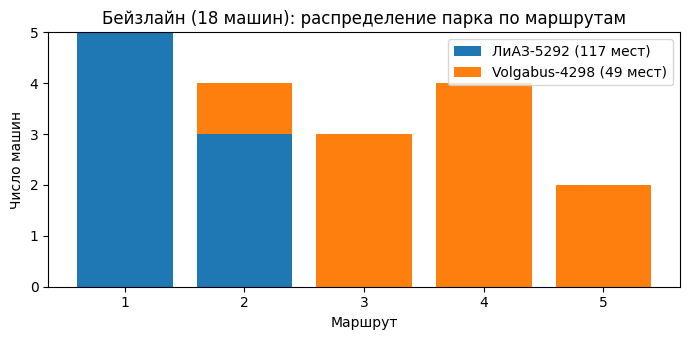

In [174]:
def fleet_table(routes, fleet, label=""):
    """Таблица: сколько машин какого типа выделено каждому маршруту,
    интервал движения, провозимость и поток. veh/headway/cap/flow_per_hour
    уже считаются внутри evaluate(detail=True) — здесь просто выводим."""
    Tavg, det = evaluate(routes, detail=True)
    rows = []
    for i, r in enumerate(routes):
        veh = det['veh'][i]
        n_liaz  = sum(1 for v in veh if v == 117)
        n_volga = sum(1 for v in veh if v == 49)
        cap, flow = det['cap'][i], det['flow_per_hour'][i]
        rows.append(dict(
            Маршрут=i+1, Остановок=len(r),
            Время_в_пути_мин=round(route_oneway_time(r)/60, 1),
            Машин=len(veh), ЛиАЗ=n_liaz, Volgabus=n_volga,
            Интервал_мин=round(det['headway'][i]/60, 1) if np.isfinite(det['headway'][i]) else None,
            Провозимость_пасс_ч=round(cap, 0),
            Поток_пасс_ч=round(flow, 0),
            Загрузка_pct=round(100*flow/cap, 0) if cap > 0 else None,
        ))
    df = pd.DataFrame(rows)
    used = sum(len(v) for v in det['veh'].values())
    print(f"{label} T_avg = {Tavg/60:.2f} мин | машин использовано: {used}/{len(fleet)}")
    display(df)

    # столбчатая диаграмма: состав парка по маршрутам
    fig, ax = plt.subplots(figsize=(7, 3.5))
    x = df['Маршрут']
    ax.bar(x, df['ЛиАЗ'], label='ЛиАЗ-5292 (117 мест)', color='tab:blue')
    ax.bar(x, df['Volgabus'], bottom=df['ЛиАЗ'], label='Volgabus-4298 (49 мест)', color='tab:orange')
    ax.set_xlabel('Маршрут'); ax.set_ylabel('Число машин')
    ax.set_title(f'{label} распределение парка по маршрутам')
    ax.legend(); ax.set_xticks(x)
    plt.tight_layout(); plt.show()
    return df

FLEET = make_fleet(8, 10)
_ = fleet_table(saved_routes['18 машин (факт)'], FLEET, "Бейзлайн (18 машин):")

## 9.2 Метрика: «пешком быстрее, чем на автобусе»
Доля населения, для которой прямая пешая дорога до метро (со скоростью 5 км/ч)
короче, чем поездка на оптимизированном автобусе `T_i`.

Нужен файл с пешеходными расстояниями **подъезд → метро по сети** (не по прямой),
например `podyezd_dist_to_metro.csv`. По умолчанию ищем его рядом с ноутбуком —
при необходимости поправьте `PODYEZD_DIST_PATH`. Названия колонок определяются
автоматически (ищем id-колонку и колонку с «dist» в названии); если не угадалось —
поправьте `id_col`/`dist_col` руками, ориентируясь на распечатанный список колонок.

In [175]:
import os

PODYEZD_DIST_PATH = r"C:\Users\georg\NIS\Curse_work_2026\podyezd_dist_to_metro.csv"  # <- поправьте путь при необходимости

if not os.path.exists(PODYEZD_DIST_PATH):
    print(f"Файл не найден: {PODYEZD_DIST_PATH}")
    print("Положите его рядом с ноутбуком или укажите полный путь в PODYEZD_DIST_PATH.")
else:
    walk_df = pd.read_csv(PODYEZD_DIST_PATH)
    print("Колонки файла:", walk_df.columns.tolist())

    # автоопределение колонок — при необходимости задайте вручную
    id_col   = next((c for c in walk_df.columns
                     if c.lower() in ('entrance_id','id','fid','podyezd_id')), walk_df.columns[0])
    dist_col = next((c for c in walk_df.columns if 'dist' in c.lower()), walk_df.columns[1])
    print(f"id_col='{id_col}', dist_col='{dist_col}' (предполагаем расстояние в метрах)")

    walk_df = (walk_df[[id_col, dist_col]]
               .rename(columns={id_col: 'entrance_id', dist_col: 'dist_m'}))
    walk_df['t_walk_direct_s'] = walk_df['dist_m'] / P['walk_speed_mps']

    cmp_df = pd.DataFrame({'entrance_id': EIDS, 'population': POP, 't_bus_s': ent_time})
    cmp_df = cmp_df.merge(walk_df[['entrance_id','t_walk_direct_s']], on='entrance_id', how='left')

    n_missing = cmp_df['t_walk_direct_s'].isna().sum()
    if n_missing:
        print(f"Внимание: {n_missing} подъездов не нашлись в файле — исключены из расчёта")
    cmp_df = cmp_df.dropna(subset=['t_walk_direct_s'])

    walk_faster = cmp_df['t_walk_direct_s'] < cmp_df['t_bus_s']
    pct_pop = cmp_df.loc[walk_faster, 'population'].sum() / cmp_df['population'].sum() * 100

    print(f"\nПодъездов, где пешком быстрее: {walk_faster.sum()} / {len(cmp_df)}")
    print(f"Доля населения, для которой пешком до метро быстрее автобуса: {pct_pop:.1f}%")

    top = (cmp_df.loc[walk_faster]
           .assign(t_walk_min=lambda d: (d['t_walk_direct_s']/60).round(1),
                   t_bus_min=lambda d: (d['t_bus_s']/60).round(1))
           [['entrance_id','population','t_walk_min','t_bus_min']]
           .sort_values('population', ascending=False).head(10))
    display(top)

Колонки файла: ['podyezd', 'distance_to_metro_m']
id_col='podyezd', dist_col='distance_to_metro_m' (предполагаем расстояние в метрах)
Внимание: 1 подъездов не нашлись в файле — исключены из расчёта

Подъездов, где пешком быстрее: 2 / 620
Доля населения, для которой пешком до метро быстрее автобуса: 0.5%


,entrance_id,population,t_walk_min,t_bus_min
352,353,270.473684,30.7,60.0
543,544,204.500000,28.6,60.0


## 10. Экспорт маршрутов в GeoPackage (для QGIS)
Строим геометрию каждого выбранного маршрута вдоль графа и сохраняем слои `routes` и `served_stops`.

In [176]:
def route_polyline(route):
    node_seq = [board_nodes[s] for s in route] + [metro_nodes[0]]
    coords = []
    for a, b in zip(node_seq[:-1], node_seq[1:]):
        try: path = nx.shortest_path(G, a, b, weight='time')
        except nx.NetworkXNoPath: continue
        coords += path if not coords else path[1:]
    return LineString(coords) if len(coords) >= 2 else None

sel = saved_routes['18 машин (факт)']
rows = [dict(route_id=i+1, n_stops=len(r), geometry=route_polyline(r))
        for i, r in enumerate(sel) if route_polyline(r)]
routes_gdf = gpd.GeoDataFrame(rows, crs=CRS)
routes_gdf.to_file(r"C:\Users\georg\NIS\Curse_work_2026\baseline_routes_v2.gpkg", layer='routes', driver='GPKG')

served_idx = sorted(set(s for r in sel for s in r))
board.iloc[served_idx].to_file(r"C:\Users\georg\NIS\Curse_work_2026\baseline_routes_v2.gpkg", layer='served_stops', driver='GPKG')
print(f"Сохранено baseline_routes.gpkg: {len(routes_gdf)} маршрутов, {len(served_idx)} остановок")

Сохранено baseline_routes.gpkg: 5 маршрутов, 21 остановок


## 11. Визуализация в Python (matplotlib)

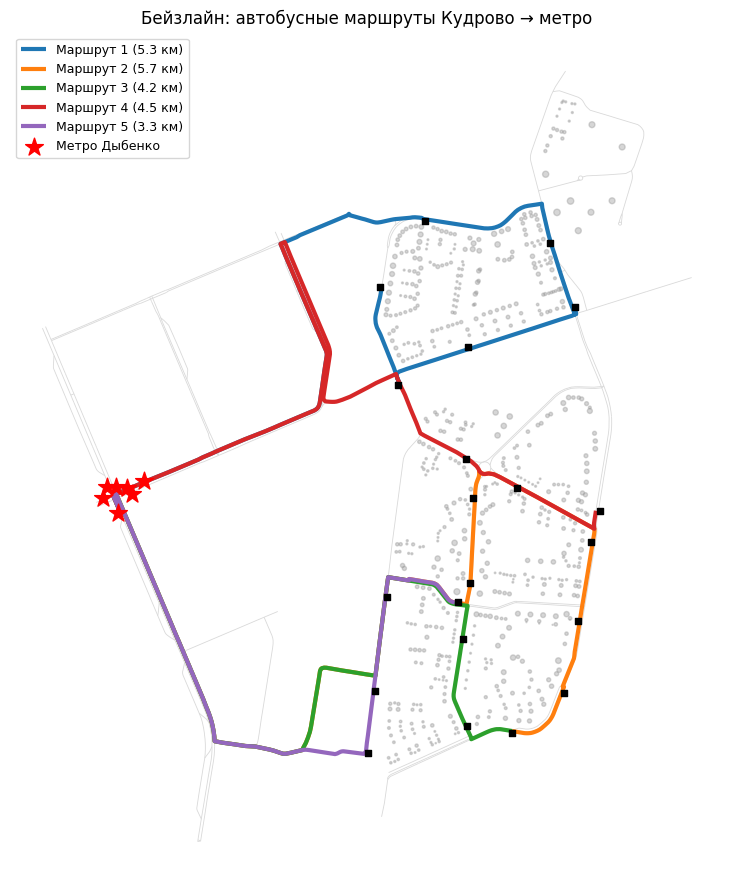

In [177]:
roads = gpd.read_file('C:/Users/georg/NIS/Curse_work_2026/kud_roads_buses_v3.gpkg', layer='doroga_for_busiki').to_crs(CRS)
fig, ax = plt.subplots(figsize=(11, 9))
roads.plot(ax=ax, color='0.85', lw=0.6, zorder=1)
ent.plot(ax=ax, color='0.6', markersize=ent['population']/30, alpha=0.4, zorder=2)
cmap = plt.cm.tab10
for i, (_, r) in enumerate(routes_gdf.iterrows()):
    gpd.GeoSeries([r.geometry], crs=CRS).plot(ax=ax, color=cmap(i), lw=3, zorder=4,
        label=f"Маршрут {r['route_id']} ({r.geometry.length/1000:.1f} км)")
board.iloc[served_idx].plot(ax=ax, color='black', markersize=22, marker='s', zorder=5)
metro.plot(ax=ax, color='red', markersize=180, marker='*', zorder=6, label='Метро Дыбенко')
ax.legend(loc='upper left', fontsize=9)
ax.set_title('Бейзлайн: автобусные маршруты Кудрово → метро')
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 12. Визуализация в QGIS
1. **Layer → Add Layer → Add Vector Layer** → выбрать `baseline_routes.gpkg`.
   Добавятся слои `routes` (линии маршрутов) и `served_stops` (обслуживаемые остановки).
2. Для разноцветных маршрутов: правый клик по `routes` → **Properties → Symbology** →
   **Categorized** → Value: `route_id` → **Classify**.
3. Подложка: **Plugins → QuickMapServices → OSM Standard** (или **OpenStreetMap**).
4. Подписи маршрутов: **Properties → Labels → Single labels** → Value: `route_id`.
5. Сравнение со старыми: добавьте слой `existing_routes` из `OUTPUT.gpkg` и положите
   рядом полупрозрачным, чтобы визуально сопоставить трассы.

## Что показывает бейзлайн (для выводов курсовой)
- Простой топологический метод **без ML** уже заметно превосходит текущую сеть по `T_avg`.
- Но у него есть **видимые слабости**: он концентрирует парк на нескольких маршрутах и
  оставляет ~1% населения без прямого обслуживания (видно по `Обслужено_pct`). Жадность
  застревает в локальном оптимуме. Именно эти слабости и должны улучшать методы ML
  (генетический алгоритм / RL) — что и составит основной результат работы.
